# Phase 4 — Evaluation & Analysis

**Objective.** Quantitatively and qualitatively evaluate the trained CRNN-CTC
model on the held-out test split of the RealBook-PrIMuS dataset. We measure
the **Symbol Error Rate (SER)** — edit distance at the LMX token level —
then drill into per-sample statistics, representative predictions, and
failure modes.

| Section | Purpose |
|---|---|
| 1. Setup & Initialisation | Load config, vocab, model checkpoint |
| 2. Test Dataset Loading | Instantiate the held-out test split |
| 3. Training Curves | Plot loss & SER from the training log |
| 4. Quantitative Evaluation | Aggregate SER over the full test set |
| 5. Qualitative Analysis | Visual side-by-side of predictions |
| 6. Error Analysis | Worst-case failures & error-type breakdown |

---
## 1. Setup & Initialisation

Import all required libraries, apply the project-wide style, load the
configuration dataclass, vocabulary mapping, and the best saved model
checkpoint. The model is set to evaluation mode and moved to the
appropriate device (GPU if available).

In [1]:
# ── Project-wide style ──────────────────────────────────────────────────
import sys
sys.path.insert(0, "../src")  # CRNN_CTC.* imports
sys.path.insert(0, "..")      # src.* pickle paths (checkpoint compatibility)
import style; style.apply()

# ── Standard / third-party ──────────────────────────────────────────────
import collections
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.amp import autocast
from torch.utils.data import DataLoader

# ── Project modules ─────────────────────────────────────────────────────
from CRNN_CTC.config import Config
from CRNN_CTC.vocab import Vocabulary
from CRNN_CTC.model import CRNN
from CRNN_CTC.dataset import make_splits, collate_fn
from CRNN_CTC.evaluate import greedy_decode, _edit_distance, symbol_error_rate

# ── Paths (relative to notebook dir, resolved via Config) ───────────────
NOTEBOOK_DIR = Path.cwd()
cfg = Config()

# Make paths absolute (Config stores repo-relative paths)
DATA_DIR   = (NOTEBOOK_DIR / ".." / cfg.data_dir).resolve()
VOCAB_PATH = (NOTEBOOK_DIR / ".." / cfg.vocab_path).resolve()
CHECKPOINT = (NOTEBOOK_DIR / ".." / cfg.model_dir / "best_model.pt").resolve()
LOG_PATH   = (NOTEBOOK_DIR / ".." / cfg.model_dir / "training_log.csv").resolve()

print(f"Data dir   : {DATA_DIR}")
print(f"Vocab path : {VOCAB_PATH}")
print(f"Checkpoint : {CHECKPOINT}")
print(f"Log path   : {LOG_PATH}")

Data dir   : /var/home/pol-linux/Uni/TFG-OMR/data/realbook_primus_aa
Vocab path : /var/home/pol-linux/Uni/TFG-OMR/src/CRNN_CTC/vocabulary.txt
Checkpoint : /var/home/pol-linux/Uni/TFG-OMR/models/best_model.pt
Log path   : /var/home/pol-linux/Uni/TFG-OMR/models/training_log.csv


In [2]:
# ── Device ──────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = device.type == "cuda"
print(f"Device: {device}  |  AMP: {use_amp}")

# ── Vocabulary ──────────────────────────────────────────────────────────
vocab = Vocabulary.from_file(VOCAB_PATH)
print(f"Vocabulary size: {len(vocab)} tokens (incl. blank + pad)")

# ── Module alias fix ────────────────────────────────────────────────────
# The checkpoint was serialised with PyTorch pickle using 'src.CRNN_CTC.*'
# module paths (training ran from the repo root with src/ on sys.path as a
# namespace). The notebook only adds '../src', so 'CRNN_CTC' is importable
# but 'src.CRNN_CTC' is not. We inject aliases so pickle can find them.
import importlib, types as _types
_src = sys.modules.setdefault("src", _types.ModuleType("src"))
import CRNN_CTC as _pkg
sys.modules.setdefault("src.CRNN_CTC", _pkg)
for _sub in ("config", "vocab", "model", "dataset", "train", "evaluate"):
    _mod = importlib.import_module(f"CRNN_CTC.{_sub}")
    sys.modules.setdefault(f"src.CRNN_CTC.{_sub}", _mod)

# ── Model ───────────────────────────────────────────────────────────────
ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
model = CRNN(
    vocab_size=ckpt.get("vocab_size", len(vocab)),
    cnn_out_channels=cfg.cnn_out_channels,
    rnn_hidden=cfg.rnn_hidden,
    rnn_layers=cfg.rnn_layers,
    dropout=0.0,  # no dropout at inference
).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

n_params = sum(p.numel() for p in model.parameters())
best_epoch = ckpt.get("epoch", -1)
best_ser   = ckpt.get("val_ser", -1)
print(f"Parameters : {n_params:,}")
print(f"Best epoch : {best_epoch}  |  Val SER @ save: {best_ser:.4f}")


Device: cuda  |  AMP: True
Vocabulary size: 94 tokens (incl. blank + pad)
Parameters : 4,229,598
Best epoch : 36  |  Val SER @ save: 0.0712


---
## 2. Test Dataset Loading

We use the same deterministic split (`seed=42`) as training to guarantee
the test set is the exact held-out partition the model has **never** seen.
The dataloader fetches batches without shuffling so results are reproducible.

In [3]:
_, _, test_ds = make_splits(
    data_dir=DATA_DIR,
    vocab=vocab,
    img_height=cfg.img_height,
    scanned_dir=None,
    val_frac=cfg.val_frac,
    test_frac=cfg.test_frac,
    seed=cfg.seed,
)

test_loader = DataLoader(
    test_ds,
    batch_size=cfg.batch_size,
    shuffle=False,
    num_workers=cfg.num_workers,
    collate_fn=collate_fn,
    pin_memory=True,
)

print(f"Test samples : {len(test_ds)}")
print(f"Test batches : {len(test_loader)}")

Test samples : 3096
Test batches : 194


---
## 3. Training Curves

Plot loss and SER evolution over the training run to verify convergence
and detect over-fitting. The dashed vertical line marks the epoch whose
checkpoint we loaded.

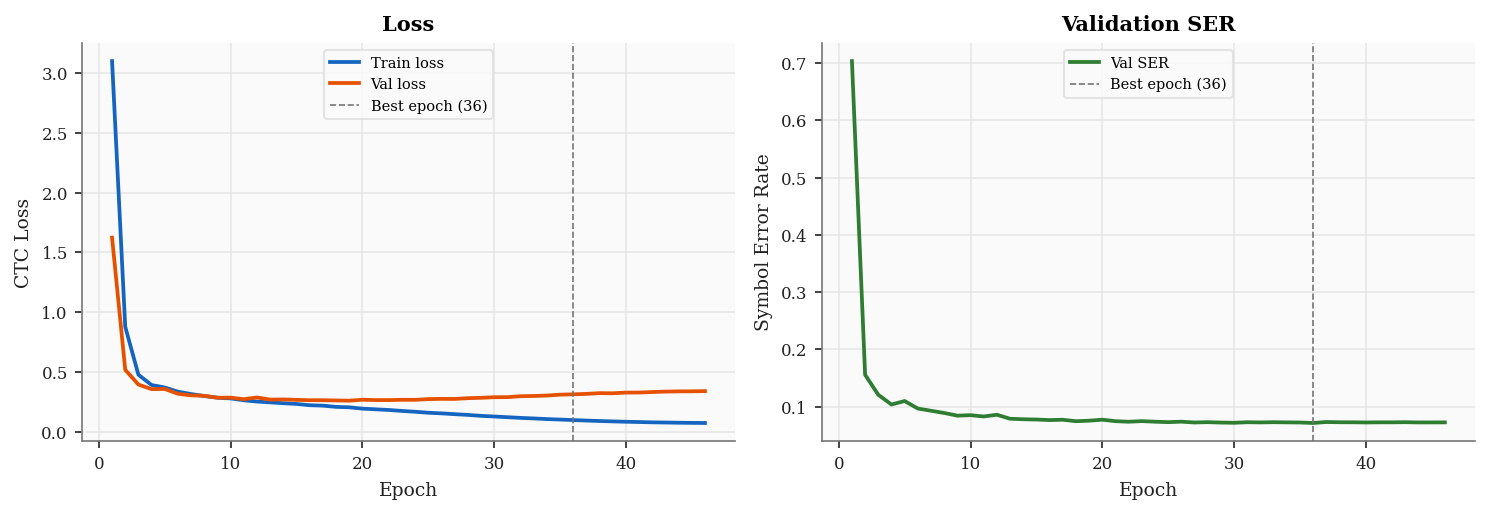

Final training loss : 0.0754
Best  val SER       : 0.0712 (epoch 36)


In [4]:
import csv

# Parse the training log
epochs, train_loss, val_loss, val_ser = [], [], [], []
with open(LOG_PATH) as f:
    reader = csv.DictReader(f)
    for r in reader:
        epochs.append(int(r["epoch"]))
        train_loss.append(float(r["train_loss"]))
        val_loss.append(float(r["val_loss"]))
        val_ser.append(float(r["val_ser"]))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

# ── Loss curves ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, train_loss, label="Train loss", color=style.C["primary"])
ax.plot(epochs, val_loss,   label="Val loss",   color=style.C["secondary"])
ax.axvline(best_epoch, ls="--", lw=0.8, color=style.C["neutral_mid"],
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("CTC Loss")
ax.set_title("Loss")
ax.legend(fontsize=7)

# ── SER curve ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, val_ser, color=style.C["tertiary"], label="Val SER")
ax.axvline(best_epoch, ls="--", lw=0.8, color=style.C["neutral_mid"],
           label=f"Best epoch ({best_epoch})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Symbol Error Rate")
ax.set_title("Validation SER")
ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

print(f"Final training loss : {train_loss[-1]:.4f}")
print(f"Best  val SER       : {min(val_ser):.4f} (epoch {epochs[int(np.argmin(val_ser))]})")

---
## 4. Quantitative Evaluation — Global Metrics

Run inference over the **entire** test set in `torch.inference_mode()`.
For every sample we store the predicted sequence, the ground-truth sequence,
the edit distance, and the per-sample SER.

$$
\text{SER} = \frac{\sum_i \operatorname{edit\_dist}(\hat{y}_i, y_i)}
              {\sum_i |y_i|}
$$

In [5]:
results: list[dict] = []  # per-sample records
total_edits = 0
total_syms  = 0

with torch.inference_mode():
    for batch in test_loader:
        images      = batch["images"].to(device)
        labels      = batch["labels"].to(device)
        label_lens  = batch["label_lens"].to(device)
        image_widths = batch["image_widths"].to(device)
        sids        = batch["sample_ids"]

        with autocast("cuda", enabled=use_amp):
            log_probs, output_lens = model(images, image_widths)

        preds = greedy_decode(log_probs, output_lens, vocab)

        # Unpack flat CTC targets into per-sample ground-truth lists
        offset = 0
        for i, length in enumerate(label_lens):
            l = length.item()
            ref = vocab.decode(labels[offset : offset + l].tolist())
            offset += l

            ed  = _edit_distance(preds[i], ref)
            ser = ed / max(len(ref), 1)

            total_edits += ed
            total_syms  += len(ref)

            results.append({
                "sid":  sids[i],
                "pred": preds[i],
                "ref":  ref,
                "ed":   ed,
                "ser":  ser,
            })

agg_ser = total_edits / max(total_syms, 1)
sers    = np.array([r["ser"] for r in results])

print(f"{'Test samples':.<30s} {len(results):>8d}")
print(f"{'Total edits':.<30s} {total_edits:>8d}")
print(f"{'Total reference symbols':.<30s} {total_syms:>8d}")
print(f"{'Aggregate SER':.<30s} {agg_ser:>8.4f}")
print(f"{'Median per-sample SER':.<30s} {np.median(sers):>8.4f}")
print(f"{'Perfect predictions (SER=0)':.<30s} {(sers == 0).sum():>8d}  "
      f"({(sers == 0).mean() * 100:.1f}%)")
print(f"{'SER ≤ 0.05':.<30s} {(sers <= 0.05).sum():>8d}  "
      f"({(sers <= 0.05).mean() * 100:.1f}%)")
print(f"{'SER ≤ 0.10':.<30s} {(sers <= 0.10).sum():>8d}  "
      f"({(sers <= 0.10).mean() * 100:.1f}%)")
print(f"{'SER > 1.0':.<30s} {(sers > 1.0).sum():>8d}  "
      f"({(sers > 1.0).mean() * 100:.1f}%)")

Test samples..................     3096
Total edits...................    11293
Total reference symbols.......   151698
Aggregate SER.................   0.0744
Median per-sample SER.........   0.0213
Perfect predictions (SER=0)...     1393  (45.0%)
SER ≤ 0.05....................     1875  (60.6%)
SER ≤ 0.10....................     2325  (75.1%)
SER > 1.0.....................        0  (0.0%)


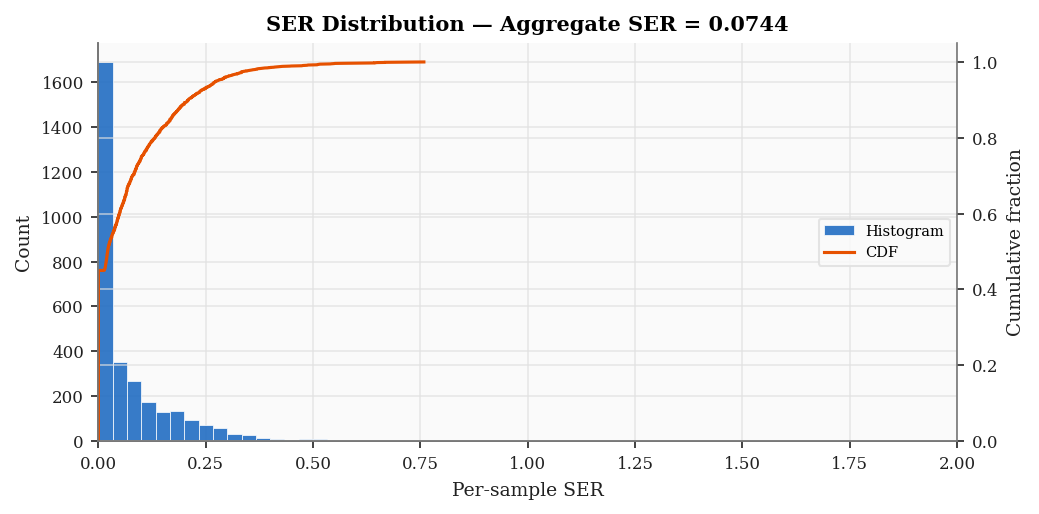

In [6]:
# ── SER distribution histogram + CDF overlay ──────────────────────────
clipped = np.clip(sers, 0, 2.0)  # clip outliers for readability

fig, ax = plt.subplots(figsize=(7, 3.5))
bins = np.linspace(0, 2.0, 61)
ax.hist(clipped, bins=bins, color=style.C["primary"], edgecolor="white",
        linewidth=0.4, alpha=0.85, label="Histogram")

# CDF on a twin axis
ax2 = ax.twinx()
sorted_ser = np.sort(sers)
cdf = np.arange(1, len(sorted_ser) + 1) / len(sorted_ser)
ax2.plot(sorted_ser, cdf, color=style.C["secondary"], lw=1.5, label="CDF")
ax2.set_ylabel("Cumulative fraction")
ax2.set_ylim(0, 1.05)
ax2.spines["right"].set_visible(True)

ax.set_xlabel("Per-sample SER")
ax.set_ylabel("Count")
ax.set_title(f"SER Distribution — Aggregate SER = {agg_ser:.4f}")
ax.set_xlim(0, 2.0)

# Combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="center right", fontsize=7)

fig.tight_layout()
plt.show()

---
## 5. Qualitative Analysis — Visual Inspection

Randomly sample a handful of test images and display them alongside
their **ground-truth** and **predicted** LMX token sequences. For each
sample the edit distance is printed so we can immediately gauge prediction
quality.

In [7]:
import textwrap

def show_predictions(
    results: list[dict],
    test_ds,
    *,
    indices: np.ndarray | None = None,
    n: int = 6,
    seed: int = 0,
    title_prefix: str = "",
) -> None:
    """Plot *n* test images, each immediately followed by GT / PRED text.

    Each sample is emitted as its own figure + print block so the text
    output sits directly below its image in the notebook.
    """
    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(len(results), size=min(n, len(results)), replace=False)
        indices = np.sort(indices)

    if title_prefix:
        print(f"{'─' * 70}")
        print(f"  {title_prefix}")
        print(f"{'─' * 70}\n")

    WRAP = 110  # characters per line for token sequences

    for i, idx in enumerate(indices):
        r = results[idx]
        sample = test_ds[idx]
        img = sample["image"].squeeze(0).numpy()

        # ── One figure per sample ────────────────────────────────────────
        fig, ax = plt.subplots(figsize=(13, 2.2))
        ax.imshow(img, cmap="gray", aspect="auto")
        ax.set_xticks([])
        ax.set_yticks([])

        ser_colour = (style.C["tertiary"]  if r["ser"] < 0.05
                      else style.C["secondary"] if r["ser"] < 0.30
                      else style.C["highlight"])
        ax.set_title(
            f"[{i+1}/{len(indices)}]  {r['sid']}   "
            f"ED = {r['ed']}   SER = {r['ser']:.3f}",
            fontsize=9, color=ser_colour, loc="left", pad=4,
        )
        fig.tight_layout()
        plt.show()

        # ── GT / PRED as plain printed text ──────────────────────────────
        ref_str  = " ".join(r["ref"])  if r["ref"]  else "(empty)"
        pred_str = " ".join(r["pred"]) if r["pred"] else "(empty)"

        indent = "         "  # align continuation lines with the token start
        gt_lines   = textwrap.fill(ref_str,  width=WRAP,
                                   initial_indent="GT:    ",
                                   subsequent_indent=indent)
        pred_lines = textwrap.fill(pred_str, width=WRAP,
                                   initial_indent="PRED:  ",
                                   subsequent_indent=indent)

        print(gt_lines)
        print(pred_lines)
        print()


──────────────────────────────────────────────────────────────────────
  Random sample — qualitative check
──────────────────────────────────────────────────────────────────────



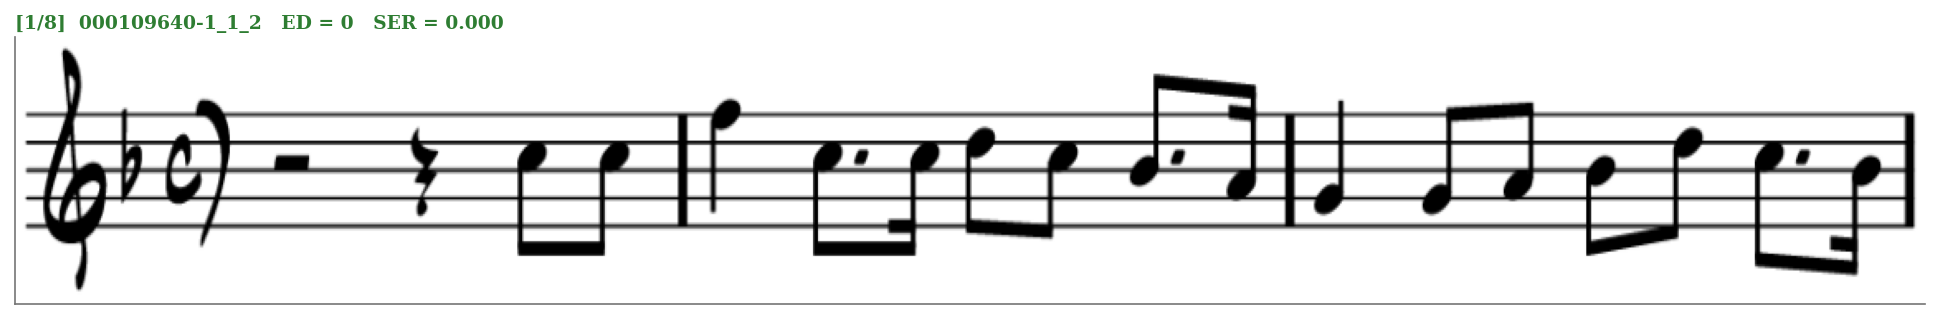

GT:    measure key:fifths:-1 time beats:4 beat-type:4 clef:G2 rest rest:measure measure rest half rest quarter
         C5 eighth C5 eighth measure F5 quarter C5 eighth dot C5 16th D5 eighth C5 eighth B4 eighth dot A4
         16th measure G4 quarter G4 eighth A4 eighth B4 eighth D5 eighth C5 eighth dot B4 16th
PRED:  measure key:fifths:-1 time beats:4 beat-type:4 clef:G2 rest rest:measure measure rest half rest quarter
         C5 eighth C5 eighth measure F5 quarter C5 eighth dot C5 16th D5 eighth C5 eighth B4 eighth dot A4
         16th measure G4 quarter G4 eighth A4 eighth B4 eighth D5 eighth C5 eighth dot B4 16th



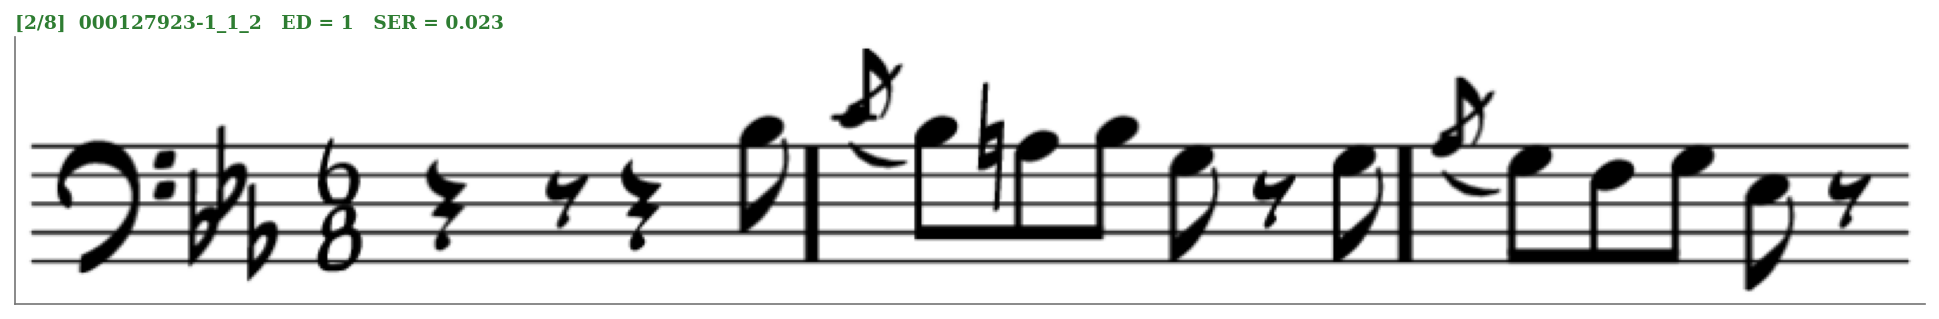

GT:    measure key:fifths:-3 time beats:6 beat-type:8 clef:F4 rest rest:measure measure rest quarter rest
         eighth rest quarter B3 eighth measure B3 eighth A3 eighth natural B3 eighth G3 eighth rest eighth G3
         eighth measure G3 eighth F3 eighth G3 eighth E3 eighth rest eighth rest eighth
PRED:  measure key:fifths:-3 time beats:6 beat-type:8 clef:F4 rest rest:measure measure rest quarter rest
         eighth rest quarter B3 eighth measure B3 eighth A3 eighth natural B3 eighth G3 eighth rest eighth G3
         eighth measure G3 eighth F3 eighth G3 eighth E3 eighth rest eighth rest quarter



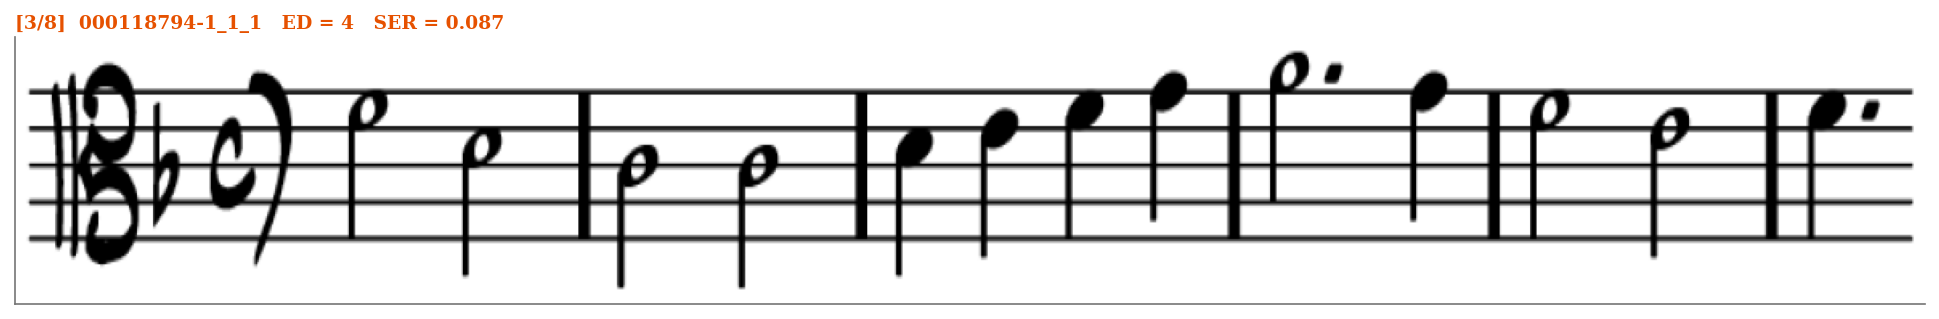

GT:    measure key:fifths:-1 time beats:4 beat-type:4 clef:C3 rest rest:measure measure F4 half D4 half
         measure C4 half C4 half measure D4 quarter E4 quarter F4 quarter G4 quarter measure A4 half dot G4
         quarter measure F4 half E4 half measure F4 quarter dot rest half rest eighth
PRED:  measure key:fifths:-1 time beats:4 beat-type:4 clef:C3 F4 half D4 half measure C4 half C4 half measure
         D4 quarter E4 quarter F4 quarter G4 quarter measure A4 half dot G4 quarter measure F4 half E4 half
         measure F4 quarter dot rest half rest dot



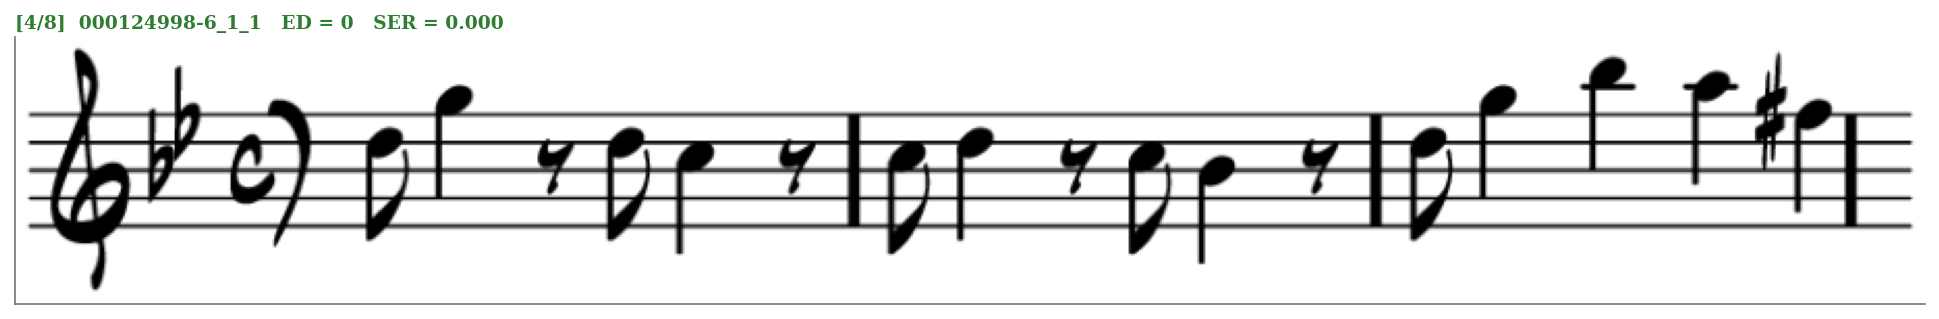

GT:    measure key:fifths:-2 time beats:4 beat-type:4 clef:G2 D5 eighth rest half dot dot measure G5 quarter
         rest eighth D5 eighth C5 quarter rest eighth C5 eighth measure D5 quarter rest eighth C5 eighth B4
         quarter rest eighth D5 eighth measure G5 quarter B5 quarter A5 quarter F5 quarter sharp
PRED:  measure key:fifths:-2 time beats:4 beat-type:4 clef:G2 D5 eighth rest half dot dot measure G5 quarter
         rest eighth D5 eighth C5 quarter rest eighth C5 eighth measure D5 quarter rest eighth C5 eighth B4
         quarter rest eighth D5 eighth measure G5 quarter B5 quarter A5 quarter F5 quarter sharp



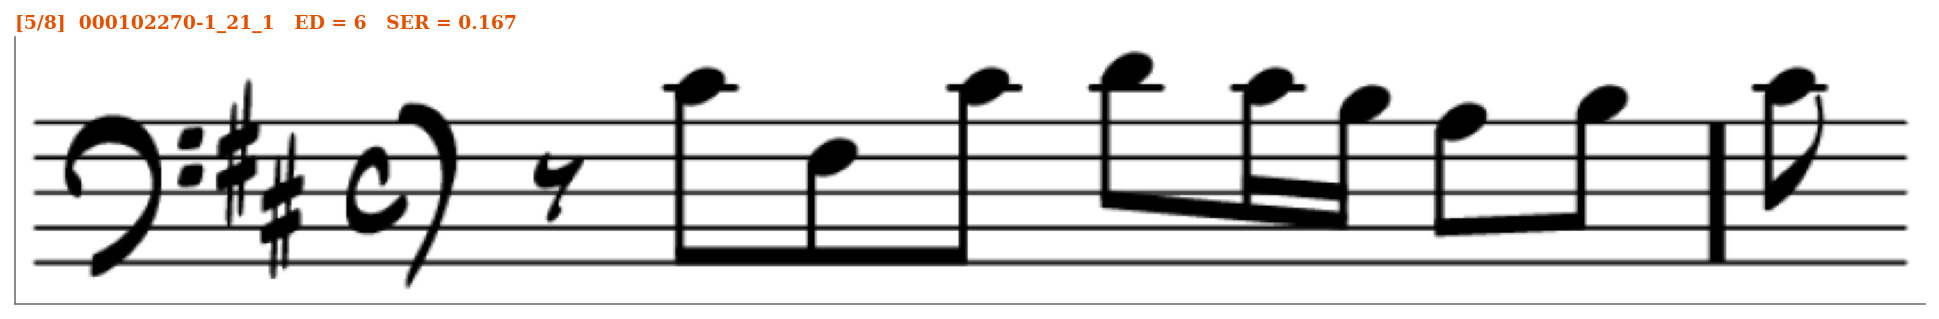

GT:    measure key:fifths:2 time beats:4 beat-type:4 clef:F4 rest eighth C4 eighth F3 eighth C4 eighth rest
         half measure D4 eighth C4 16th B3 16th A3 eighth B3 eighth rest half measure C4 eighth rest half dot
         dot
PRED:  measure key:fifths:2 time beats:4 beat-type:4 clef:F4 rest eighth C4 eighth F3 eighth C4 eighth D4
         eighth C4 16th B3 16th A3 eighth B3 eighth measure C4 eighth rest half dot



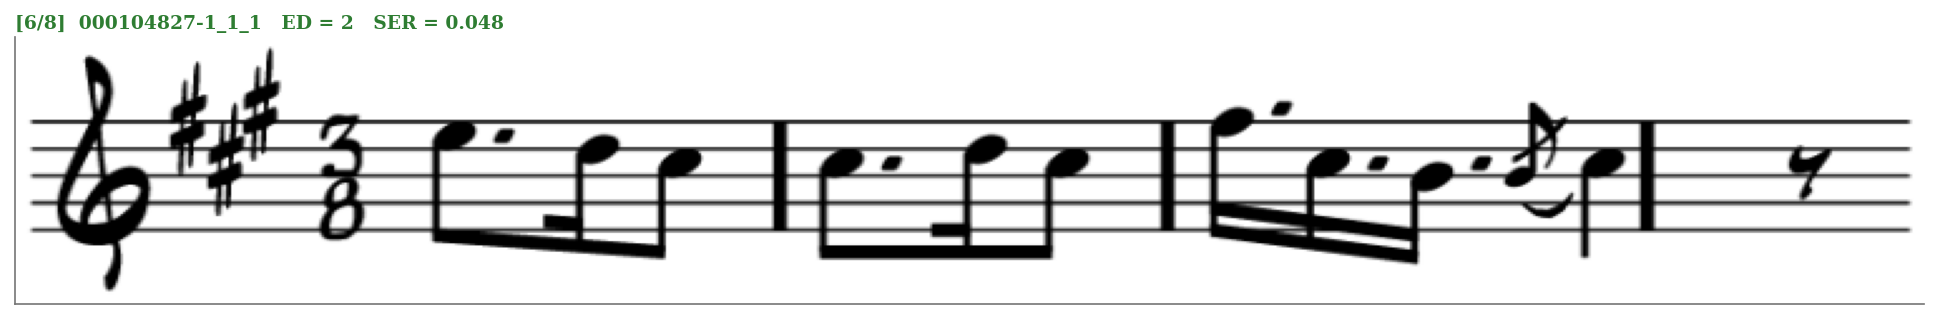

GT:    measure key:fifths:3 time beats:3 beat-type:8 clef:G2 E5 eighth dot D5 16th C5 eighth measure C5 eighth
         dot D5 16th C5 eighth measure D5 32nd F5 16th dot E5 32nd C5 16th dot D5 32nd B4 16th dot measure C5
         quarter rest eighth
PRED:  measure key:fifths:3 time beats:3 beat-type:8 clef:G2 E5 eighth dot D5 16th C5 eighth measure C5 eighth
         dot D5 16th C5 eighth measure D5 32nd F5 16th dot E5 32nd C5 16th dot D5 32nd B4 16th dot measure C5
         quarter rest eighth rest eighth



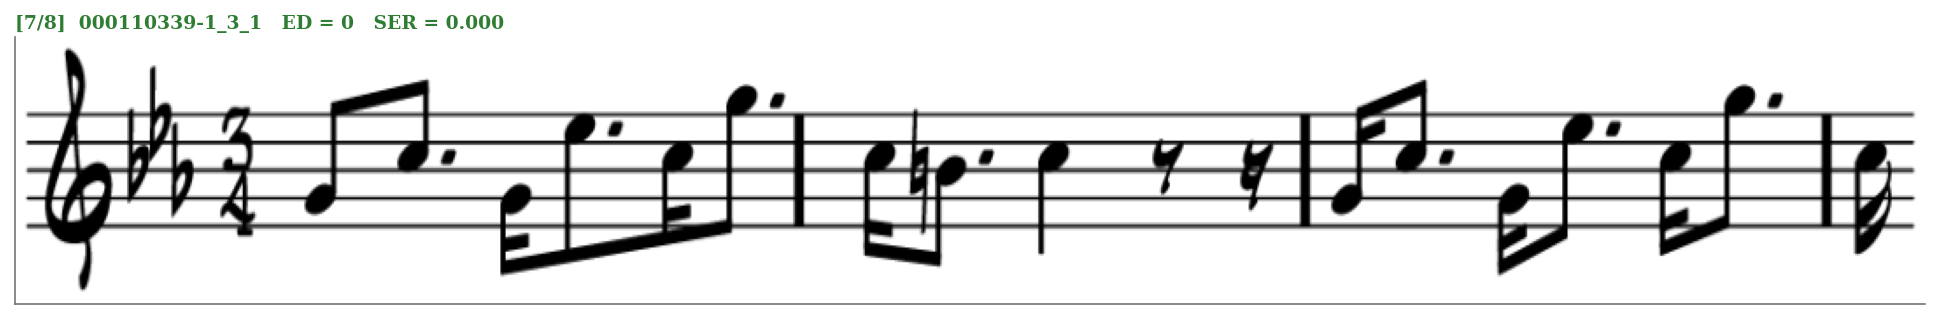

GT:    measure key:fifths:-3 time beats:3 beat-type:4 clef:G2 G4 eighth rest half rest eighth measure C5
         eighth dot G4 16th E5 eighth dot C5 16th G5 eighth dot C5 16th measure B4 eighth dot natural C5 32nd
         D5 32nd C5 quarter rest eighth rest 16th G4 16th measure C5 eighth dot G4 16th E5 eighth dot C5 16th
         G5 eighth dot C5 16th
PRED:  measure key:fifths:-3 time beats:3 beat-type:4 clef:G2 G4 eighth rest half rest eighth measure C5
         eighth dot G4 16th E5 eighth dot C5 16th G5 eighth dot C5 16th measure B4 eighth dot natural C5 32nd
         D5 32nd C5 quarter rest eighth rest 16th G4 16th measure C5 eighth dot G4 16th E5 eighth dot C5 16th
         G5 eighth dot C5 16th



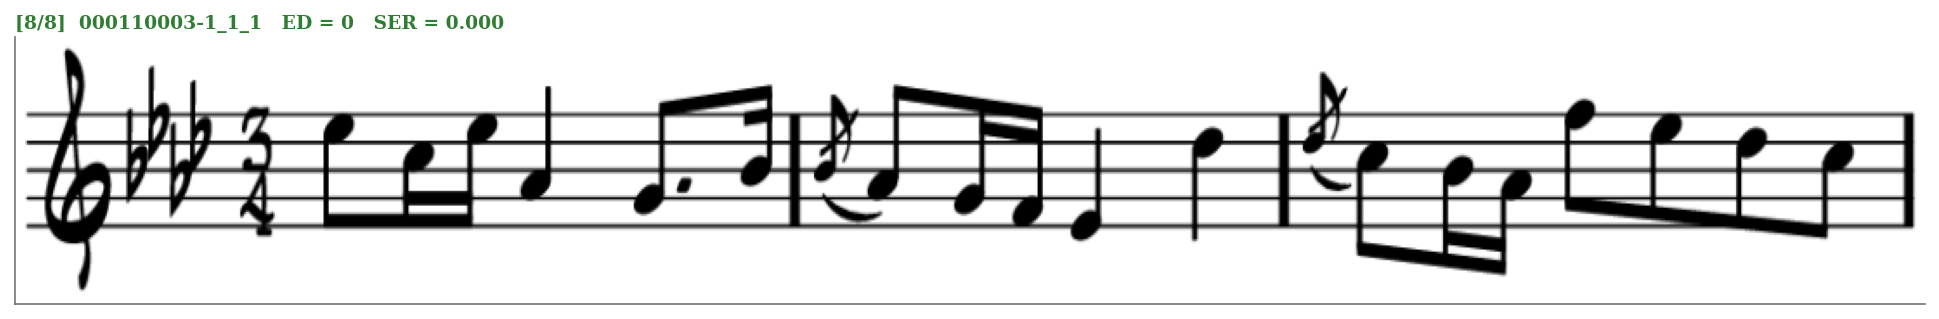

GT:    measure key:fifths:-4 time beats:3 beat-type:4 clef:G2 E5 eighth C5 16th E5 16th A4 quarter G4 eighth
         dot B4 16th measure A4 eighth G4 16th F4 16th E4 quarter D5 quarter measure C5 eighth B4 16th A4 16th
         F5 eighth E5 eighth D5 eighth C5 eighth
PRED:  measure key:fifths:-4 time beats:3 beat-type:4 clef:G2 E5 eighth C5 16th E5 16th A4 quarter G4 eighth
         dot B4 16th measure A4 eighth G4 16th F4 16th E4 quarter D5 quarter measure C5 eighth B4 16th A4 16th
         F5 eighth E5 eighth D5 eighth C5 eighth



In [8]:
show_predictions(results, test_ds, n=8, seed=42,
                 title_prefix="Random sample — qualitative check")

### 5.1 Near-median examples

To give a representative picture of *typical* model performance we also
show samples whose SER is close to the **median** of the distribution.

Median SER = 0.0213  |  tolerance = ±0.01  | 286 candidates
──────────────────────────────────────────────────────────────────────
  Near-median examples
──────────────────────────────────────────────────────────────────────



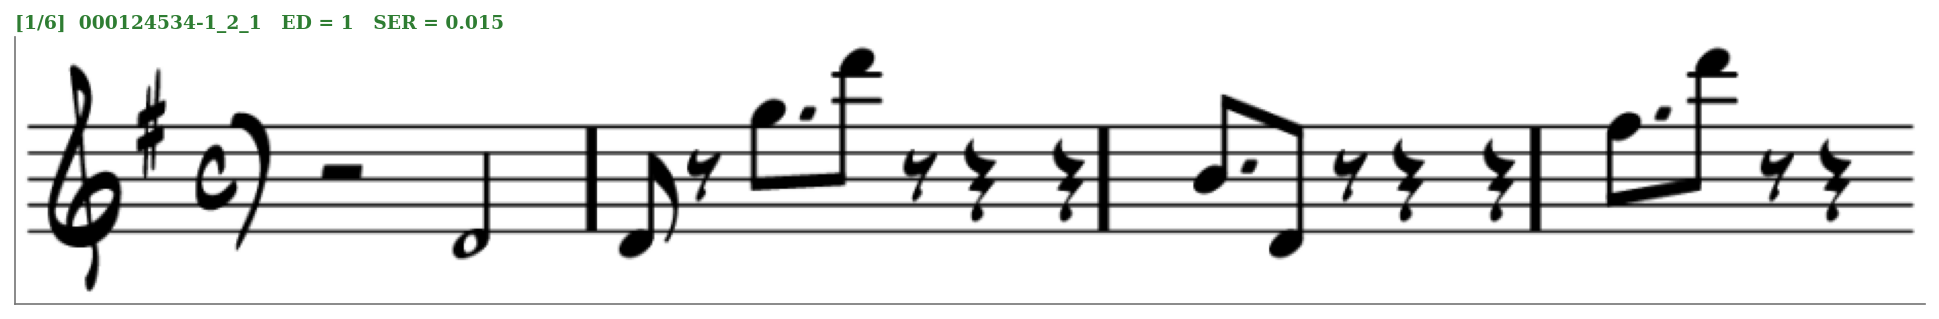

GT:    measure key:fifths:1 time beats:4 beat-type:4 clef:G2 rest rest:measure measure rest half D4 half
         tied:start measure D4 eighth tied:stop rest eighth B5 32nd A5 32nd G5 eighth dot D6 eighth rest
         eighth rest quarter measure rest quarter G4 32nd A4 32nd B4 eighth dot D4 eighth rest eighth rest
         quarter measure rest quarter B5 32nd G5 32nd F5 eighth dot D6 eighth rest eighth rest quarter
PRED:  measure key:fifths:1 time beats:4 beat-type:4 clef:G2 rest rest:measure measure rest half D4 half
         tied:start measure D4 eighth tied:stop rest eighth B5 32nd A5 32nd G5 eighth dot D6 eighth rest
         eighth rest quarter measure rest quarter G4 32nd A4 32nd B4 eighth dot D4 eighth rest eighth rest
         quarter measure rest quarter 32nd G5 32nd F5 eighth dot D6 eighth rest eighth rest quarter



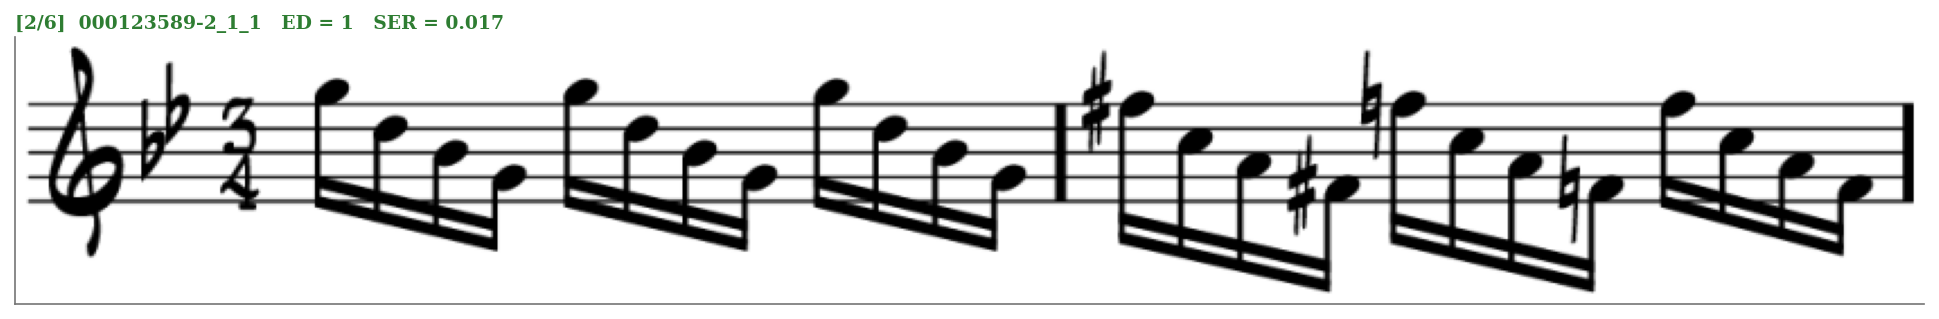

GT:    measure key:fifths:-2 time beats:3 beat-type:4 clef:G2 G5 16th D5 16th B4 16th G4 16th G5 16th D5 16th
         B4 16th G4 16th G5 16th D5 16th B4 16th G4 16th measure F5 16th sharp C5 16th A4 16th F4 16th sharp
         F5 16th natural C5 16th A4 16th F4 16th natural F5 16th C5 16th A4 16th F4 16th
PRED:  measure key:fifths:-2 time beats:3 beat-type:4 clef:G2 G5 16th D5 16th B4 16th G4 16th G5 16th D5 16th
         B4 16th G4 16th G5 16th D5 16th B4 16th G4 16th measure F5 16th sharp C5 16th A4 16th F4 16th sharp
         A5 16th natural C5 16th A4 16th F4 16th natural F5 16th C5 16th A4 16th F4 16th



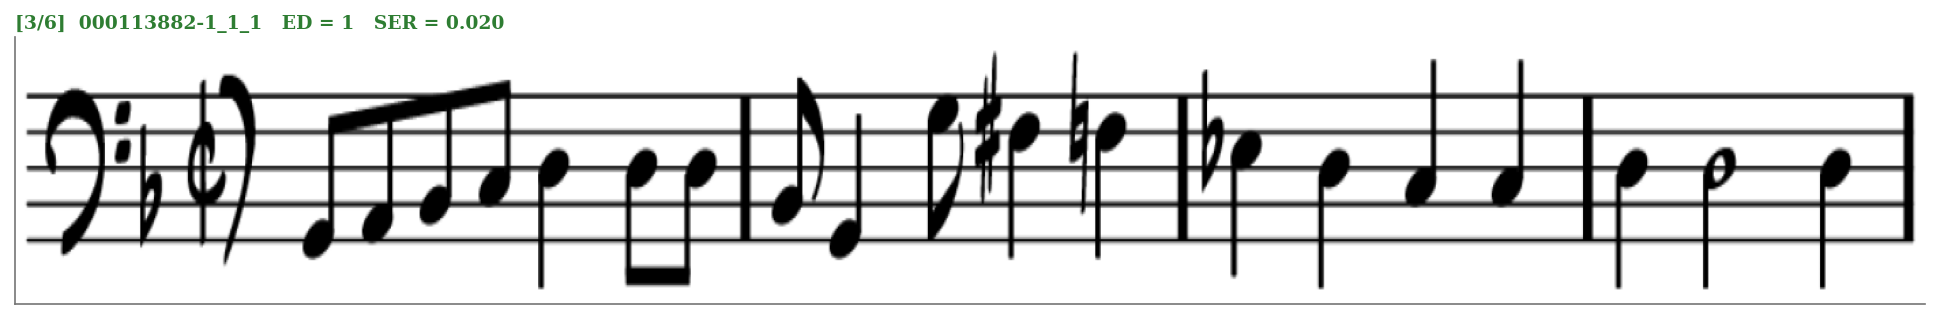

GT:    measure key:fifths:-1 time beats:2 beat-type:2 clef:F4 G2 eighth A2 eighth B2 eighth C3 eighth D3
         quarter D3 eighth D3 eighth measure B2 eighth G2 quarter G3 eighth F3 quarter sharp F3 quarter
         natural measure E3 quarter flat D3 quarter C3 quarter C3 quarter measure D3 quarter D3 half D3
         quarter
PRED:  measure key:fifths:-1 time beats:2 beat-type:2 clef:F4 G2 eighth A2 eighth B2 eighth C3 eighth D3
         quarter D3 eighth D3 eighth measure B2 eighth G2 quarter G3 eighth F3 quarter sharp F3 quarter
         natural measure E3 quarter flat D3 quarter C3 quarter C3 quarter measure D3 quarter measure D3 half
         D3 quarter



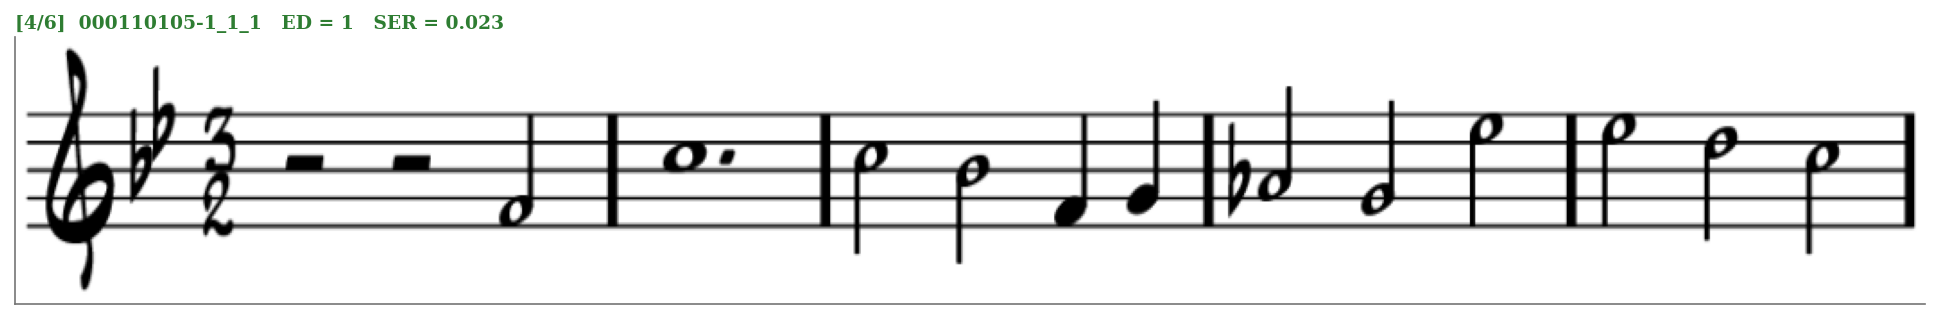

GT:    measure key:fifths:-2 time beats:3 beat-type:2 clef:G2 rest half rest half F4 half measure C5 whole dot
         tied:start measure C5 half tied:stop B4 half F4 quarter G4 quarter measure A4 half flat G4 half E5
         half tied:start measure E5 half tied:stop D5 half C5 half
PRED:  measure key:fifths:-2 time beats:3 beat-type:2 clef:G2 rest half rest half F4 half measure C5 whole dot
         tied:start measure C5 half tied:stop B4 half F4 quarter G4 quarter measure A4 half flat G4 half E5
         half tied:start measure E5 half tied:stop D5 half C5 half natural



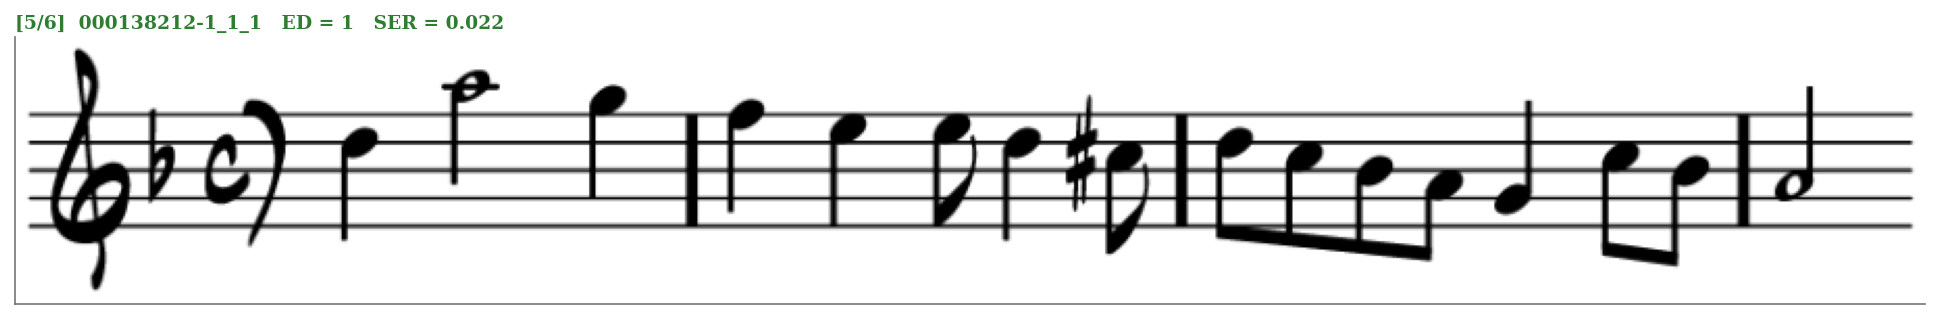

GT:    measure key:fifths:-1 time beats:4 beat-type:4 clef:G2 D5 quarter A5 half G5 quarter measure F5 quarter
         E5 quarter E5 eighth D5 quarter C5 eighth sharp measure D5 eighth C5 eighth natural B4 eighth A4
         eighth G4 quarter C5 eighth B4 eighth measure A4 half rest half
PRED:  measure key:fifths:-1 time beats:4 beat-type:4 clef:G2 D5 quarter A5 half G5 quarter measure F5 quarter
         E5 quarter E5 eighth D5 quarter C5 eighth sharp measure D5 eighth C5 eighth B4 eighth A4 eighth G4
         quarter C5 eighth B4 eighth measure A4 half rest half



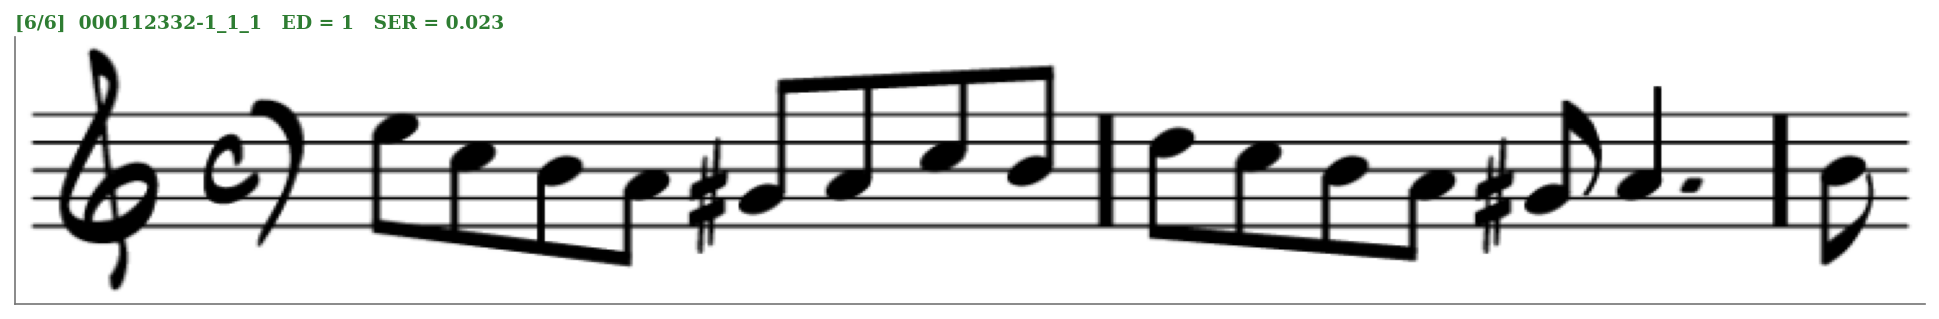

GT:    measure time beats:4 beat-type:4 clef:G2 E5 eighth rest half dot dot measure C5 eighth B4 eighth A4
         eighth G4 eighth sharp A4 eighth C5 eighth B4 eighth D5 eighth measure C5 eighth B4 eighth A4 eighth
         G4 eighth sharp A4 quarter dot B4 eighth
PRED:  measure time beats:4 beat-type:4 clef:G2 E5 eighth rest half dot dot measure C5 eighth B4 eighth A4
         eighth G4 eighth sharp A4 eighth C5 eighth B4 eighth D5 eighth measure C5 eighth B4 eighth A4 eighth
         G4 eighth sharp measure A4 quarter dot B4 eighth



In [9]:
median_ser = np.median(sers)
tolerance  = 0.01
near_median = np.where(np.abs(sers - median_ser) <= tolerance)[0]

# Widen tolerance if too few matches
while len(near_median) < 6 and tolerance < 0.5:
    tolerance += 0.01
    near_median = np.where(np.abs(sers - median_ser) <= tolerance)[0]

chosen = np.sort(np.random.default_rng(7).choice(
    near_median, size=min(6, len(near_median)), replace=False))

print(f"Median SER = {median_ser:.4f}  |  tolerance = ±{tolerance:.2f}  "
      f"| {len(near_median)} candidates")
show_predictions(results, test_ds, indices=chosen,
                 title_prefix="Near-median examples")

---
## 6. Error Analysis — Failure Modes

### 6.1 Worst predictions

Identify the test samples with the **highest** edit distance (not SER, so
short sequences with one error do not dominate). Inspecting these reveals
systematic failure modes — e.g. heavily distorted images, unusual symbol
patterns, or excessively long sequences.

──────────────────────────────────────────────────────────────────────
  Worst predictions (highest edit distance)
──────────────────────────────────────────────────────────────────────



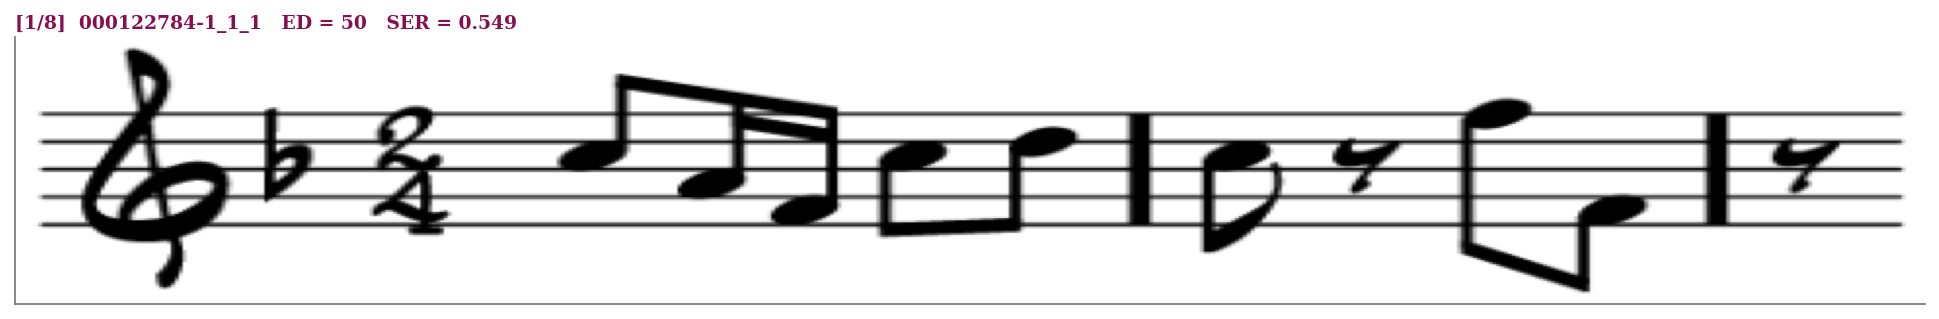

GT:    measure key:fifths:-1 time beats:2 beat-type:4 clef:G2 C5 eighth rest quarter dot measure A4 16th F4
         16th C5 eighth D5 32nd B4 32nd F5 32nd F5 32nd D5 32nd B4 32nd F5 32nd D5 32nd measure D5 eighth C5
         eighth rest eighth F5 eighth measure E5 32nd E5 32nd F5 32nd G5 32nd B4 32nd B4 32nd C5 32nd D5 32nd
         E4 32nd E4 32nd F4 32nd G4 32nd C4 32nd E4 32nd G4 32nd B4 32nd measure A4 32nd G4 32nd F4 32nd G4
         32nd F4 eighth rest eighth rest eighth
PRED:  measure key:fifths:-1 time beats:2 beat-type:4 clef:G2 C5 eighth rest quarter dot measure A4 16th A4
         16th tied:stop F4 16th C5 eighth 32nd E5 measure D5 32nd E5 32nd F5 32nd D5 32nd 32nd D5 32nd eighth
         C5 eighth E5 32nd E5 32nd E5 32nd D5 eighth 32nd measure F5 32nd eighth F4 eighth rest eighth rest
         eighth



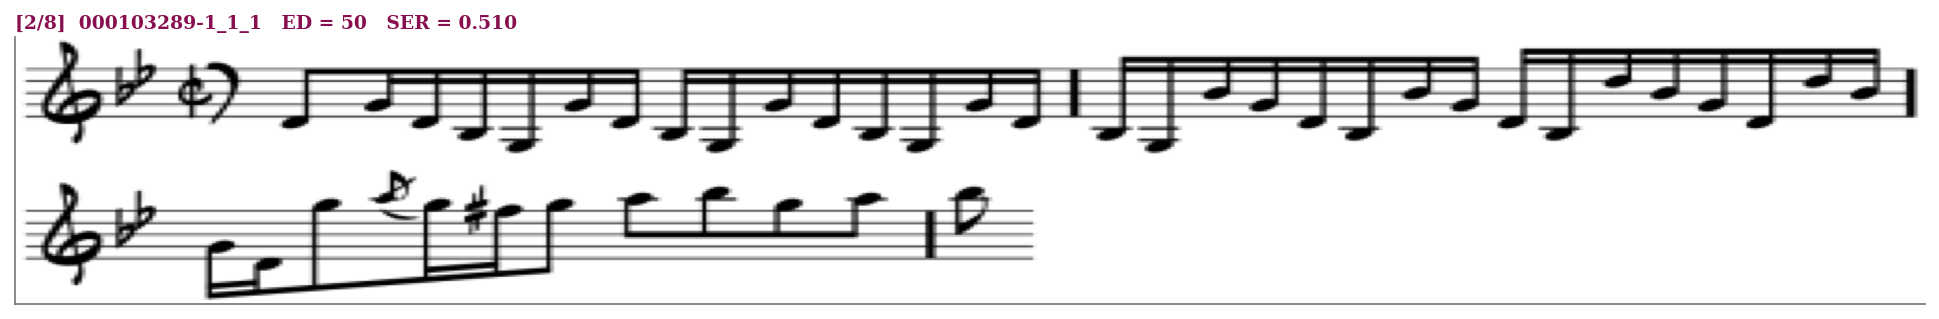

GT:    measure key:fifths:-2 time beats:2 beat-type:2 clef:G2 D4 eighth rest half dot dot measure G4 16th D4
         16th B3 16th G3 16th G4 16th D4 16th B3 16th G3 16th G4 16th D4 16th B3 16th G3 16th G4 16th D4 16th
         B3 16th G3 16th measure B4 16th G4 16th D4 16th B3 16th B4 16th G4 16th D4 16th B3 16th D5 16th B4
         16th G4 16th D4 16th D5 16th B4 16th G4 16th D4 16th measure G5 eighth G5 16th F5 16th sharp G5
         eighth A5 eighth B5 eighth G5 eighth A5 eighth B5 eighth
PRED:  measure key:fifths:-2 time beats:2 beat-type:2 clef:G2 D4 eighth 16th D4 16th D4 16th D4 16th G4 16th
         D4 16th D4 16th D4 16th D4 16th D4 16th D4 16th D4 16th D4 16th D4 16th D4 16th D4 16th E4 16th A4
         16th A4 16th G4 16th G4 16th A4 16th D5 16th A4 16th A4 16th D5 16th A4 16th D5 16th G4 16th D5 16th
         A4 16th F4 16th E4 16th rest 16th



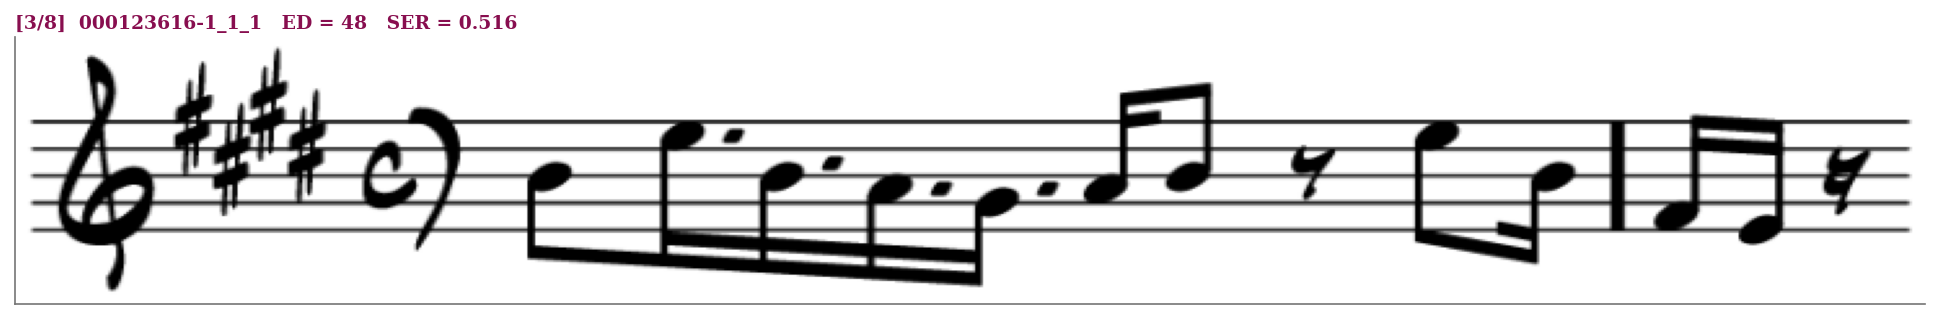

GT:    measure key:fifths:4 time beats:4 beat-type:4 clef:G2 B4 eighth rest half dot dot measure E5 16th dot
         B4 32nd B4 16th dot A4 32nd A4 16th dot G4 32nd G4 16th dot E4 32nd A4 16th B4 32nd C5 32nd B4 eighth
         rest eighth E5 eighth measure D5 32nd C5 32nd B4 32nd C5 32nd B4 32nd B4 32nd B4 16th A4 32nd B4 32nd
         A4 32nd G4 32nd F4 32nd F4 32nd F4 16th G4 32nd A4 32nd G4 32nd F4 32nd E4 32nd E4 32nd E4 16th rest
         16th rest eighth dot
PRED:  measure key:fifths:4 time beats:4 beat-type:4 clef:G2 B4 eighth rest half dot dot measure D5 32nd E5
         16th dot D5 32nd B4 16th dot B4 32nd A4 16th dot D5 32nd G4 16th dot B4 32nd A4 16th B4 eighth rest
         eighth E5 eighth measure B4 16th F4 16th E4 16th rest 16th rest half rest



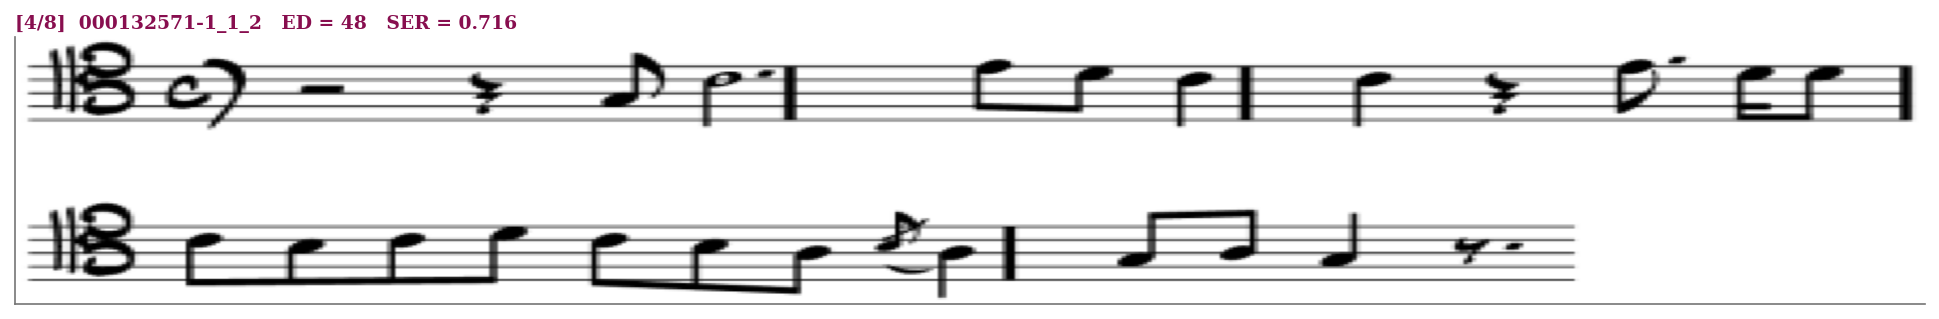

GT:    measure time beats:4 beat-type:4 clef:C4 rest rest:measure measure rest half rest quarter G3 eighth
         rest eighth measure C4 half dot E4 eighth D4 eighth measure C4 quarter C4 quarter rest quarter E4
         eighth dot D4 16th measure D4 eighth C4 eighth B3 eighth C4 eighth D4 eighth C4 eighth B3 eighth A3
         eighth measure A3 quarter G3 eighth A3 eighth G3 quarter rest eighth dot rest 16th
PRED:  measure time beats:4 beat-type:4 clef:C4 rest half rest quarter G3 quarter rest quarter C4 quarter C4
         dot C4 eighth dot measure rest eighth rest quarter measure E4 quarter measure quarter measure E4
         eighth C4 measure measure C4 16th measure D4 eighth dot measure eighth dot D4 16th D4 measure D4
         eighth D4 16th D4 16th D4 16th D4 eighth D4 16th E4 16th F4 16th 16th E4 eighth C4 eighth rest eighth
         rest quarter



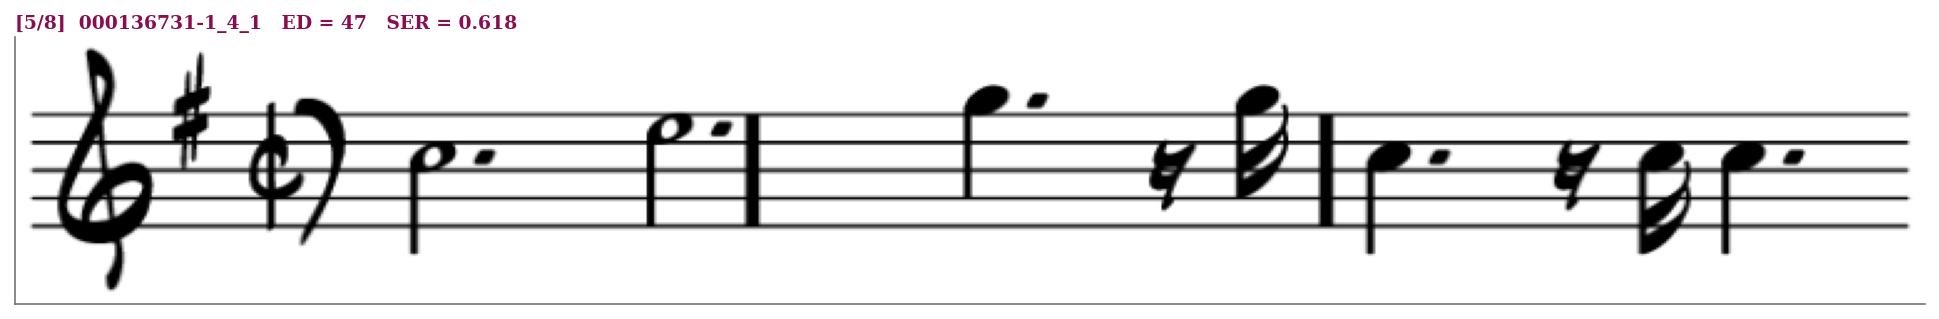

GT:    measure key:fifths:1 time beats:2 beat-type:2 clef:G2 C5 half dot rest 32nd G4 32nd A4 32nd B4 32nd C5
         32nd B4 32nd C5 32nd D5 32nd measure E5 half dot rest 32nd F5 32nd E5 32nd D5 32nd C5 32nd D5 32nd E5
         32nd F5 32nd measure G5 quarter dot rest 16th G5 16th C5 quarter dot rest 16th C5 16th measure C5
         quarter dot tied:start C5 32nd tied:stop D5 32nd E5 32nd F5 32nd rest half
PRED:  measure key:fifths:1 time beats:2 beat-type:2 clef:G2 C5 half dot measure E5 quarter measure F5 G5
         quarter dot rest 16th G5 16th C5 quarter dot rest 16th C5 16th C5 quarter dot



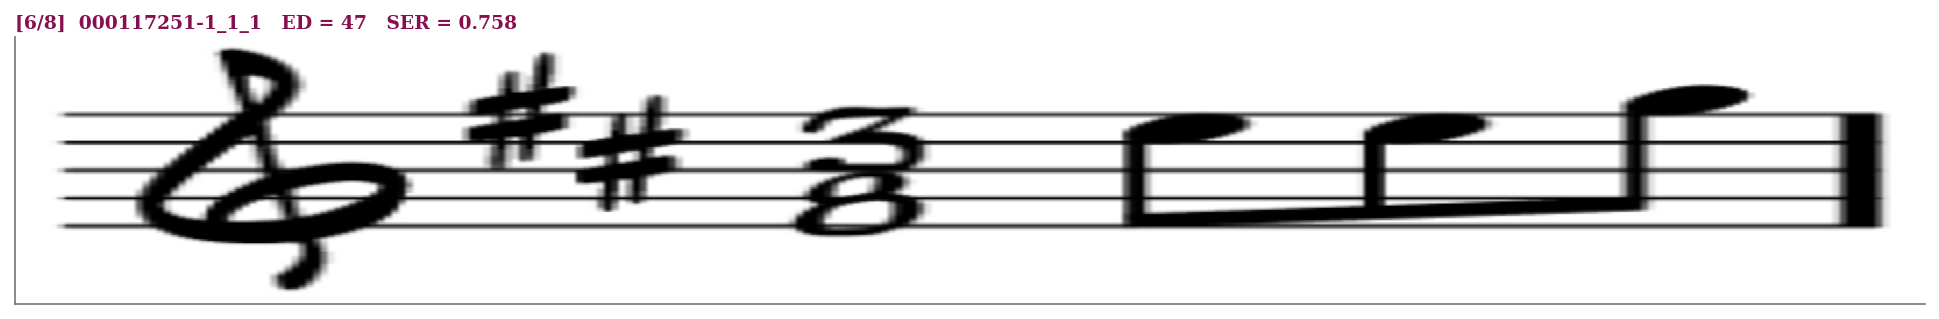

GT:    measure key:fifths:2 time beats:3 beat-type:8 clef:G2 rest rest:measure measure E5 eighth E5 eighth G5
         eighth measure F5 32nd A4 32nd G4 32nd sharp A4 32nd F5 32nd A4 32nd G4 32nd sharp A4 32nd D5 32nd A4
         32nd G4 32nd natural A4 32nd measure F5 32nd D5 32nd C5 32nd D5 32nd F5 32nd D5 32nd D6 32nd C6 32nd
         rest eighth
PRED:  measure key:fifths:2 time beats:3 beat-type:8 clef:G2 rest measure E5 eighth E5 eighth G5 eighth rest
         eighth dot



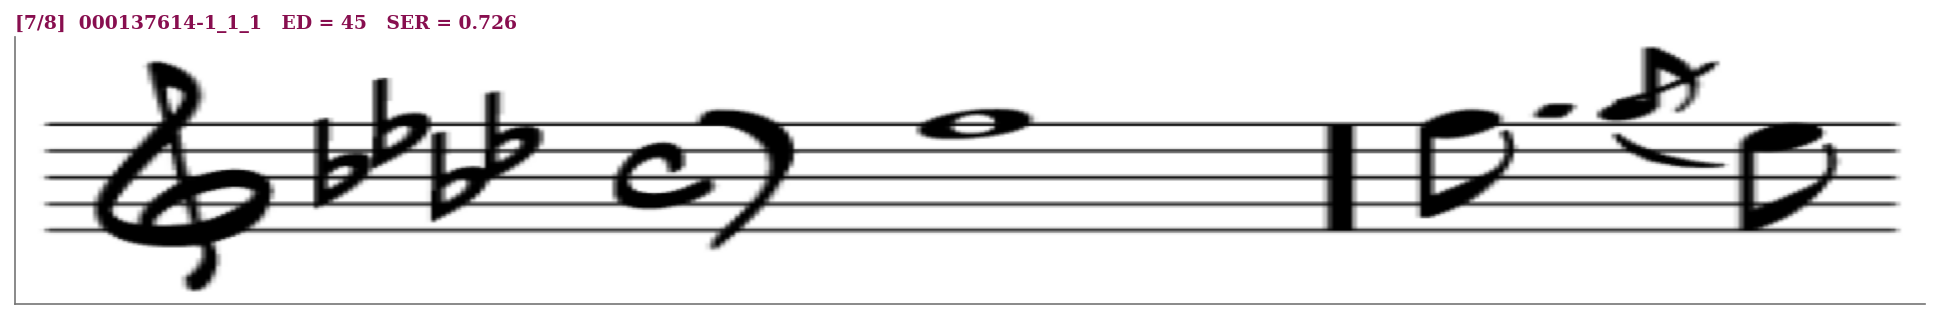

GT:    measure key:fifths:-4 time beats:4 beat-type:4 clef:G2 F5 whole measure F5 eighth dot G5 32nd F5 32nd
         E5 32nd natural F5 32nd G5 32nd A5 32nd G5 32nd B5 32nd A5 32nd G5 32nd F5 32nd F5 32nd dot E5 eighth
         flat tied:start E5 32nd tied:stop C5 32nd D5 32nd B4 32nd G4 32nd B4 32nd F4 32nd B4 32nd rest 32nd
         dot
PRED:  measure key:fifths:-4 time beats:4 beat-type:4 clef:G2 F5 whole measure F5 eighth dot F5 32nd E5 eighth
         rest half



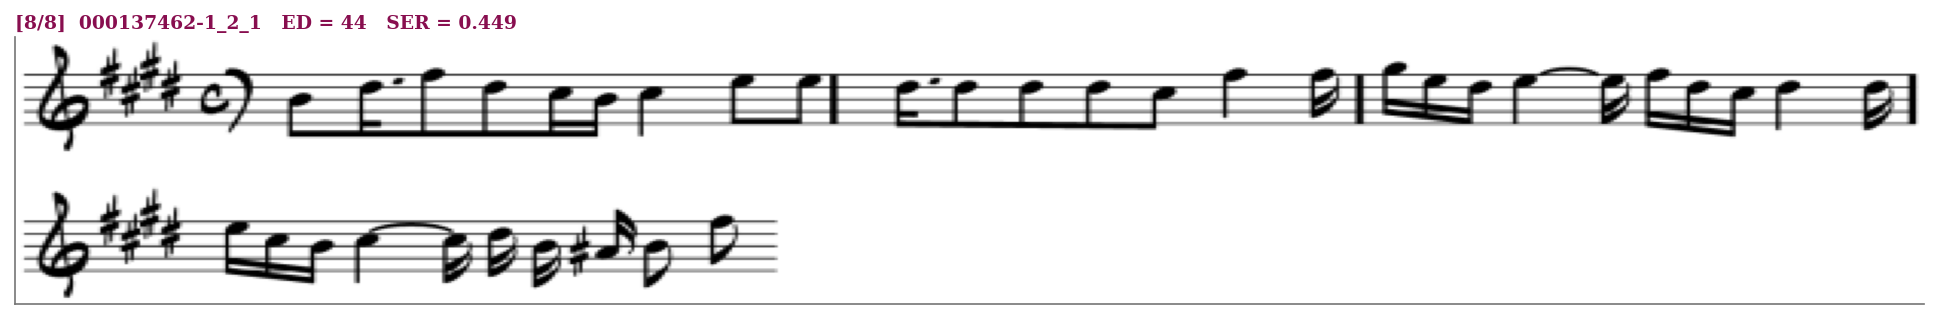

GT:    measure key:fifths:4 time beats:4 beat-type:4 clef:G2 B4 eighth D5 16th dot E5 32nd F5 eighth D5 eighth
         C5 16th B4 16th C5 quarter E5 eighth tied:start measure E5 eighth tied:stop D5 16th dot C5 32nd D5
         eighth D5 eighth D5 eighth C5 eighth F5 quarter tied:start measure F5 16th tied:stop G5 16th E5 16th
         D5 16th E5 quarter tied:start E5 16th tied:stop F5 16th D5 16th C5 16th D5 quarter tied:start measure
         D5 16th tied:stop E5 16th C5 16th B4 16th C5 quarter tied:start C5 16th tied:stop D5 16th B4 16th A4
         16th sharp B4 eighth F5 eighth
PRED:  measure key:fifths:4 time beats:4 beat-type:4 clef:G2 B4 eighth rest half dot dot measure E5 eighth F5
         eighth D5 eighth C5 16th B4 16th C5 quarter E5 eighth E5 eighth D5 eighth dot D5 eighth D5 eighth D5
         eighth D5 eighth F5 F5 16th E5 16th E5 16th E5 16th E5 16th E5 16th measure D5 16th E5 16th D5 16th
         E5 16th D5 16th D5 16th D5 16th A5 16th A5 16th F5 16th F5 16th F5 16th 

In [10]:
# Sort by raw edit distance (descending)
ed_vals = np.array([r["ed"] for r in results])
worst   = np.argsort(ed_vals)[::-1][:8]

show_predictions(results, test_ds, indices=worst,
                 title_prefix="Worst predictions (highest edit distance)")


### 6.2 Error-type breakdown (substitutions / insertions / deletions)

We trace back through the dynamic-programming matrix of the Levenshtein
algorithm to classify each edit operation. This tells us whether the model
mainly *confuses* symbols (substitution), *hallucinates* extra tokens
(insertion), or *drops* tokens (deletion).

In [11]:
def _edit_ops(hyp: list[str], ref: list[str]) -> list[str]:
    """Return the sequence of edit operations (match / sub / ins / del)
    by backtracking through the full Levenshtein matrix."""
    n, m = len(hyp), len(ref)
    # Build full DP matrix
    mat = np.zeros((n + 1, m + 1), dtype=np.int32)
    for i in range(n + 1):
        mat[i, 0] = i
    for j in range(m + 1):
        mat[0, j] = j
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            cost = 0 if hyp[i - 1] == ref[j - 1] else 1
            mat[i, j] = min(
                mat[i - 1, j] + 1,       # deletion from hyp (insertion in ref)
                mat[i, j - 1] + 1,       # insertion in hyp (deletion from ref)
                mat[i - 1, j - 1] + cost, # match / substitution
            )
    # Backtrace
    ops: list[str] = []
    i, j = n, m
    while i > 0 or j > 0:
        if i > 0 and j > 0 and mat[i, j] == mat[i-1, j-1] + (0 if hyp[i-1] == ref[j-1] else 1):
            ops.append("match" if hyp[i-1] == ref[j-1] else "sub")
            i -= 1; j -= 1
        elif i > 0 and mat[i, j] == mat[i-1, j] + 1:
            ops.append("ins")   # model inserted an extra token
            i -= 1
        else:
            ops.append("del")   # model deleted / missed a token
            j -= 1
    ops.reverse()
    return ops


# Aggregate edit operations across the full test set
total_r = {"sub": 0, "ins": 0, "del": 0, "match": 0}
sub_counts = collections.Counter()  # which token pairs are confused
del_counts = collections.Counter()  # which tokens are most often deleted
ins_counts = collections.Counter()  # which tokens are most often inserted

for r in results:
    ops = _edit_ops(r["pred"], r["ref"])
    hi, hj = 0, 0  # pointers into hyp / ref
    for op in ops:
        total_r[op] += 1
        if op == "sub":
            sub_counts[(r["ref"][hj], r["pred"][hi])] += 1
            hi += 1; hj += 1
        elif op == "ins":
            ins_counts[r["pred"][hi]] += 1
            hi += 1
        elif op == "del":
            del_counts[r["ref"][hj]] += 1
            hj += 1
        else:  # match
            hi += 1; hj += 1

total_errors = total_r["sub"] + total_r["ins"] + total_r["del"]
total_matched = total_r["match"]

print("Error-type breakdown (all test samples)")
print(f"  Substitutions : {total_r['sub']:>6d}  ({total_r['sub']/max(total_errors,1)*100:5.1f}%)")
print(f"  Insertions    : {total_r['ins']:>6d}  ({total_r['ins']/max(total_errors,1)*100:5.1f}%)")
print(f"  Deletions     : {total_r['del']:>6d}  ({total_r['del']/max(total_errors,1)*100:5.1f}%)")
print(f"  ──────────────────────────")
print(f"  Total errors  : {total_errors:>6d}")
print(f"  Matches       : {total_matched:>6d}")

Error-type breakdown (all test samples)
  Substitutions :   2597  ( 23.0%)
  Insertions    :   2612  ( 23.1%)
  Deletions     :   6084  ( 53.9%)
  ──────────────────────────
  Total errors  :  11293
  Matches       : 143017


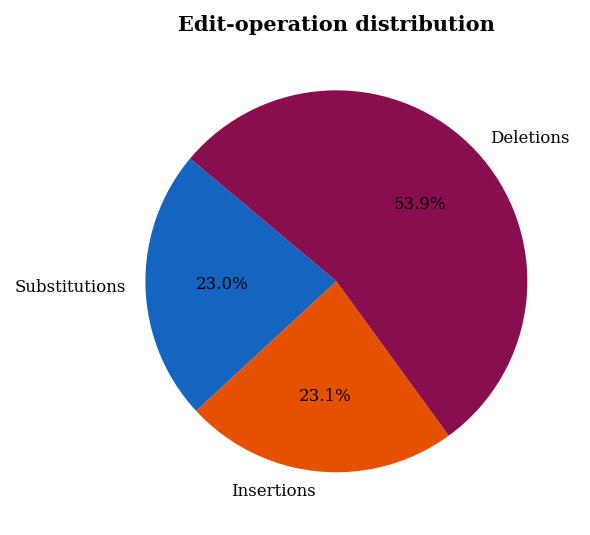

In [12]:
# ── Pie chart of error types ───────────────────────────────────────────
err_labels = ["Substitutions", "Insertions", "Deletions"]
sizes  = [total_r["sub"], total_r["ins"], total_r["del"]]
colors = [style.C["primary"], style.C["secondary"], style.C["highlight"]]

fig, ax = plt.subplots(figsize=(4, 4))
wedges, texts, autotexts = ax.pie(
    sizes, labels=err_labels, colors=colors, autopct="%1.1f%%",
    startangle=140, textprops={"fontsize": 8},
)
ax.set_title("Edit-operation distribution", fontsize=10, fontweight="bold")
fig.tight_layout()
plt.show()

### 6.3 Most common confused / deleted / inserted tokens

Rank the specific tokens (or token pairs) that contribute the most errors.
This guides targeted improvements — e.g. if durations are consistently
confused, we might augment training data with more rhythmic variety.

In [13]:
TOP_N = 15

print(f"Top-{TOP_N} substitution pairs (ref → pred):")
for (ref_tok, r_tok), cnt in sub_counts.most_common(TOP_N):
    print(f"  {ref_tok:>25s}  →  {r_tok:<25s}  ×{cnt}")

print(f"\nTop-{TOP_N} deleted tokens (model missed):")
for tok, cnt in del_counts.most_common(TOP_N):
    print(f"  {tok:>25s}  ×{cnt}")

print(f"\nTop-{TOP_N} inserted tokens (model hallucinated):")
for tok, cnt in ins_counts.most_common(TOP_N):
    print(f"  {tok:>25s}  ×{cnt}")

Top-15 substitution pairs (ref → pred):
                     eighth  →  quarter                    ×66
                     eighth  →  16th                       ×60
                       half  →  quarter                    ×41
                    quarter  →  half                       ×39
                    quarter  →  eighth                     ×39
                       16th  →  eighth                     ×34
                         C5  →  D5                         ×31
                       16th  →  quarter                    ×31
                        dot  →  eighth                     ×30
                         D5  →  F5                         ×29
                    measure  →  quarter                    ×25
                     eighth  →  dot                        ×24
                         E5  →  C5                         ×23
                        dot  →  quarter                    ×23
                         F5  →  E5                         ×23

Top-15 deleted

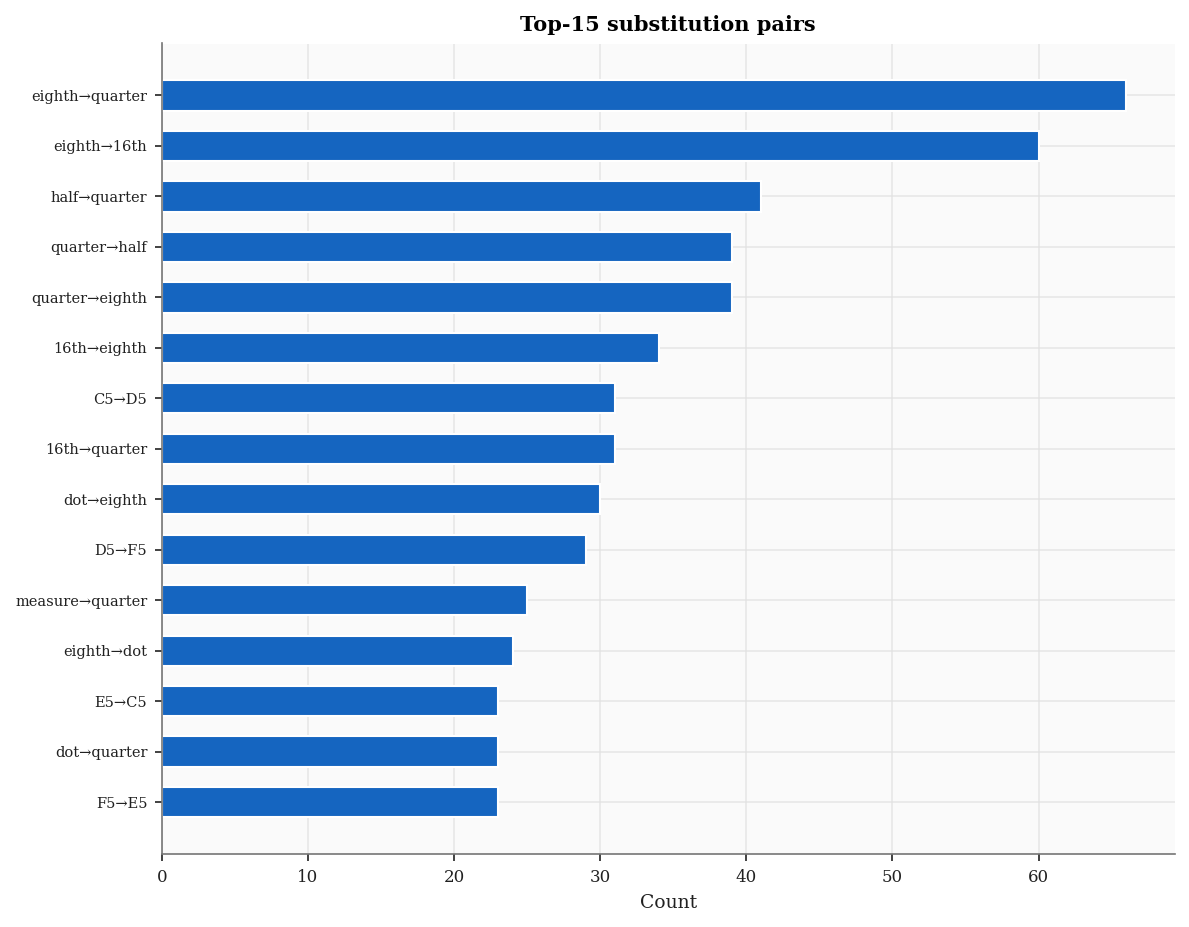

In [14]:
# ── Bar chart of top confused pairs ────────────────────────────────────
top_pairs = sub_counts.most_common(TOP_N)
if top_pairs:
    labels = [f"{a}→{b}" for (a, b), _ in top_pairs]
    vals   = [c for _, c in top_pairs]

    fig, ax = plt.subplots(figsize=(8, 0.35 * len(labels) + 1))
    y = np.arange(len(labels))
    ax.barh(y, vals, color=style.C["primary"], edgecolor="white", height=0.6)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=7)
    ax.invert_yaxis()
    ax.set_xlabel("Count")
    ax.set_title(f"Top-{TOP_N} substitution pairs", fontsize=10, fontweight="bold")
    fig.tight_layout()
    plt.show()

### 6.4 SER vs. sequence length

Scatter SER against ground-truth sequence length to check whether the
model degrades on longer (or shorter) inputs — a common failure mode
for CTC-based systems.

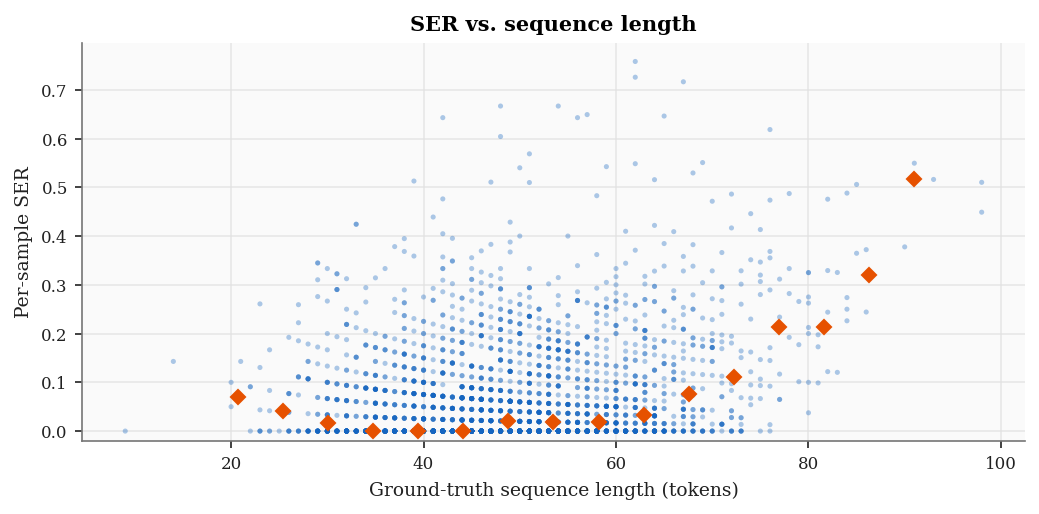

In [15]:
ref_lens = np.array([len(r["ref"]) for r in results])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.scatter(ref_lens, sers, s=6, alpha=0.35, color=style.C["primary"],
           edgecolors="none")

# Running median for trend
bins = np.linspace(ref_lens.min(), ref_lens.max(), 20)
dig  = np.digitize(ref_lens, bins)
for b in range(1, len(bins)):
    mask = dig == b
    if mask.sum() > 2:
        ax.plot(bins[b-1:b+1].mean(), np.median(sers[mask]),
                "D", ms=5, color=style.C["secondary"], zorder=5)

ax.set_xlabel("Ground-truth sequence length (tokens)")
ax.set_ylabel("Per-sample SER")
ax.set_title("SER vs. sequence length", fontsize=10, fontweight="bold")
ax.set_ylim(-0.02, min(sers.max() * 1.05, 3.0))
fig.tight_layout()
plt.show()

### 6.5 Summary

Collect the main metrics in one cell for quick reference.

In [16]:
pct_perfect = (sers == 0).mean() * 100
pct_le05    = (sers <= 0.05).mean() * 100
pct_le10    = (sers <= 0.10).mean() * 100
pct_over1   = (sers > 1.0).mean() * 100
med_ser     = float(np.median(sers))

summary = f"""
╔══════════════════════════════════════════════════╗
║        Phase 4 — Test-Set Evaluation Summary     ║
╠══════════════════════════════════════════════════╣
║  Aggregate SER          : {agg_ser:>8.4f}               ║
║  Median per-sample SER  : {med_ser:>8.4f}               ║
║  Perfect (SER = 0)      : {pct_perfect:>6.1f}%                ║
║  SER ≤ 5%               : {pct_le05:>6.1f}%                ║
║  SER ≤ 10%              : {pct_le10:>6.1f}%                ║
║  SER > 100%             : {pct_over1:>6.1f}%                ║
║  Total test samples     : {len(results):>6d}                 ║
║  Model parameters       : {n_params:>10,}             ║
║  Best checkpoint epoch  : {best_epoch:>6d}                 ║
╚══════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════╗
║        Phase 4 — Test-Set Evaluation Summary     ║
╠══════════════════════════════════════════════════╣
║  Aggregate SER          :   0.0744               ║
║  Median per-sample SER  :   0.0213               ║
║  Perfect (SER = 0)      :   45.0%                ║
║  SER ≤ 5%               :   60.6%                ║
║  SER ≤ 10%              :   75.1%                ║
║  SER > 100%             :    0.0%                ║
║  Total test samples     :   3096                 ║
║  Model parameters       :  4,229,598             ║
║  Best checkpoint epoch  :     36                 ║
╚══════════════════════════════════════════════════╝

